In [ ]:
# ── Cell 1: Imports ────────────────────────────────────────────────────────────

import os
import numpy as np
import tensorflow as tf
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, Dropout, Dense, Input, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

In [ ]:
# ── Cell 2: Config ─────────────────────────────────────────────────────────────
IMG_SIZE   = (224, 224)
BS         = 32
SEED       = 42

# Stage 1: train head only
S1_EPOCHS  = 5
S1_LR      = 1e-3

# Stage 2: fine-tune last 30 base layers
S2_EPOCHS  = 10       # EarlyStopping will stop early
S2_LR      = 1e-5     # Must be LOW when unfreezing pretrained layers

UNFREEZE_LAYERS = 30  # How many layers from the end of MobileNetV2 to unfreeze

In [ ]:
# ── Cell 3: Load Dataset ───────────────────────────────────────────────────────
path = kagglehub.dataset_download('omkargurav/face-mask-dataset')
DATASET_DIR = os.path.join(path, 'data') if 'data' in os.listdir(path) else path
print('Dataset path:', DATASET_DIR)
print('Classes found:', os.listdir(DATASET_DIR))

Using Colab cache for faster access to the 'face-mask-dataset' dataset.
Dataset path: /kaggle/input/face-mask-dataset/data
Classes found: ['without_mask', 'with_mask']


In [ ]:
# ── Cell 4: Data Generators
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.6, 1.2],
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BS,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BS,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False   # Keep order consistent for confusion matrix
)

CLASS_NAMES = list(train_gen.class_indices.keys())
print('Class indices:', train_gen.class_indices)
print('Train samples:', train_gen.samples)
print('Val samples  :', val_gen.samples)

Found 6043 images belonging to 2 classes.
Found 1510 images belonging to 2 classes.
Class indices: {'with_mask': 0, 'without_mask': 1}
Train samples: 6043
Val samples  : 1510


In [ ]:
# ── Cell 5: Class Weights ──────────────────────────────────────────────────────
# Compensates if one class has more images than the other.
labels = train_gen.classes
weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weight_dict = dict(enumerate(weights))
print('Class weights:', class_weight_dict)

Class weights: {0: np.float64(1.0139261744966444), 1: np.float64(0.9864511916421809)}


In [ ]:
# ── Cell 6: Build Model ────────────────────────────────────────────────────────
def build_model():
    base = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_tensor=Input(shape=(224, 224, 3))
    )
    # Start with ALL layers frozen for Stage 1
    base.trainable = False

    # Classification head
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(2, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=out)
    return model, base

model, baseModel = build_model()

frozen = sum(1 for l in baseModel.layers if not l.trainable)
print(f'Base layers frozen: {frozen} / {len(baseModel.layers)}')
print(f'Total model params: {model.count_params():,}')

/tmp/ipykernel_2210/340958804.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base layers frozen: 154 / 154
Total model params: 2,625,218


In [ ]:
# ── Cell 7: Callbacks (shared by both stages) ──────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-8,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_mask_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

callbacks = [early_stop, reduce_lr, checkpoint]

In [ ]:
# ── Cell 8: Stage 1 — Train Head Only ─────────────────────────────────────────
# High LR is safe here because the frozen base is untouched.
# Goal: get the new Dense layers to a reasonable starting point.

print('=' * 60)
print('STAGE 1: Training classification head only')
print(f'  LR={S1_LR}  |  Epochs={S1_EPOCHS}  |  Base: fully frozen')
print('=' * 60)

model.compile(
    optimizer=Adam(learning_rate=S1_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_s1 = model.fit(
    train_gen,
    steps_per_epoch=len(train_gen),
    validation_data=val_gen,
    validation_steps=len(val_gen),
    epochs=S1_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=[checkpoint]   # Only checkpoint in Stage 1
)

STAGE 1: Training classification head only
  LR=0.001  |  Epochs=5  |  Base: fully frozen
Epoch 1/5
107/189 ━━━━━━━━━━━━━━━━━━━━ 1:04 785ms/step - accuracy: 0.9056 - loss: 0.2263

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 723ms/step - accuracy: 0.9265 - loss: 0.1827
Epoch 1: val_loss improved from None to 0.04539, saving model to best_mask_model.keras

Epoch 1: finished saving model to best_mask_model.keras
189/189 ━━━━━━━━━━━━━━━━━━━━ 187s 863ms/step - accuracy: 0.9600 - loss: 0.1107 - val_accuracy: 0.9834 - val_loss: 0.0454
Epoch 2/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.9739 - loss: 0.0647
Epoch 2: val_loss improved from 0.04539 to 0.02803, saving model to best_mask_model.keras

Epoch 2: finished saving model to best_mask_model.keras
189/189 ━━━━━━━━━━━━━━━━━━━━ 98s 516ms/step - accuracy: 0.9747 - loss: 0.0672 - val_accuracy: 0.9914 - val_loss: 0.0280
Epoch 3/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.9785 - loss: 0.0597
Epoch 3: val_loss improved from 0.02803 to 0.02055, saving model to best_mask_model.keras

Epoch 3: finished saving model to best_mask_model.keras
189/189 ━━━━━━━━━━━━━━━━━━━━ 95s 504ms/step - accuracy: 0.9778 - loss:

In [ ]:
# ── Cell 9: Stage 2 — Fine-tune Last 30 Base Layers ───────────────────────────
# CRITICAL: use a very low LR (1e-5) to avoid destroying pretrained weights.
# Unfreezing with a high LR is the #1 cause of accuracy collapse.

print('=' * 60)
print('STAGE 2: Fine-tuning top layers of MobileNetV2')
print(f'  LR={S2_LR}  |  Max epochs={S2_EPOCHS}  |  Unfreezing last {UNFREEZE_LAYERS} layers')
print('=' * 60)

# Unfreeze last N layers of base
baseModel.trainable = True
for layer in baseModel.layers[:-UNFREEZE_LAYERS]:
    layer.trainable = False

# Keep BatchNorm layers frozen — unfreezing BN during fine-tuning causes instability
for layer in baseModel.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_now = sum(1 for l in model.layers if l.trainable)
print(f'Trainable layers: {trainable_now} / {len(model.layers)}')

# Recompile with low LR
model.compile(
    optimizer=Adam(learning_rate=S2_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Reset generators to epoch 0
train_gen.reset()
val_gen.reset()

history_s2 = model.fit(
    train_gen,
    steps_per_epoch=len(train_gen),
    validation_data=val_gen,
    validation_steps=len(val_gen),
    epochs=S2_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

STAGE 2: Fine-tuning top layers of MobileNetV2
  LR=1e-05  |  Max epochs=10  |  Unfreezing last 30 layers
Trainable layers: 27 / 162
Epoch 1/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: 0.9892 - loss: 0.0331
Epoch 1: val_loss did not improve from 0.01489
189/189 ━━━━━━━━━━━━━━━━━━━━ 129s 608ms/step - accuracy: 0.9856 - loss: 0.0413 - val_accuracy: 0.9954 - val_loss: 0.0155 - learning_rate: 1.0000e-05
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.9934 - loss: 0.0207
Epoch 2: val_loss did not improve from 0.01489
189/189 ━━━━━━━━━━━━━━━━━━━━ 97s 511ms/step - accuracy: 0.9914 - loss: 0.0254 - val_accuracy: 0.9834 - val_loss: 0.0475 - learning_rate: 1.0000e-05
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.9888 - loss: 0.0277
Epoch 3: val_loss did not improve from 0.01489
189/189 ━━━━━━━━━━━━━━━━━━━━ 97s 512ms/step - accuracy: 0.9887 - loss: 0.0302 - val_accuracy: 0.9954 - val_loss: 0.0163 - learning_rate: 1.0000e-05
Epoch 4/10
189/18

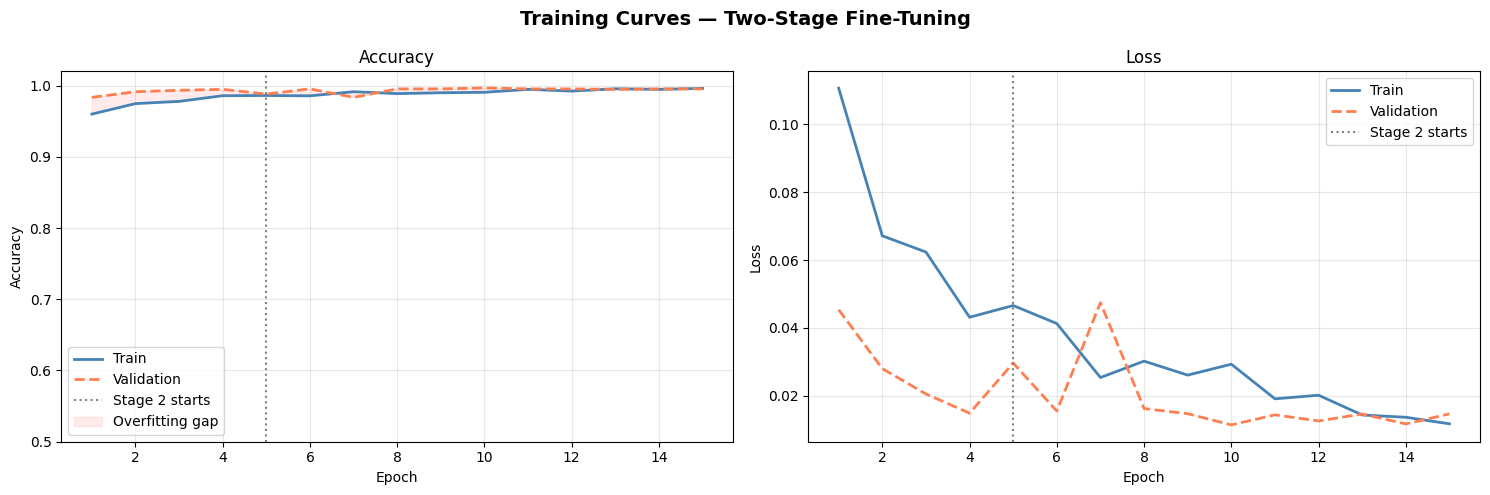

Saved: training_curves.png


In [ ]:
# ── Cell 10: Plot Training Curves ─────────────────────────────────────────────
def merge_histories(h1, h2):
    """Concatenate Stage 1 and Stage 2 history dicts."""
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged

hist = merge_histories(history_s1, history_s2)
s1_end = S1_EPOCHS  # Vertical line marking stage boundary

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Training Curves — Two-Stage Fine-Tuning', fontsize=14, fontweight='bold')

epochs_range = range(1, len(hist['accuracy']) + 1)

# Accuracy
axes[0].plot(epochs_range, hist['accuracy'],     label='Train',      color='steelblue', linewidth=2)
axes[0].plot(epochs_range, hist['val_accuracy'], label='Validation', color='coral',     linewidth=2, linestyle='--')
axes[0].axvline(x=s1_end, color='gray', linestyle=':', linewidth=1.5, label='Stage 2 starts')
axes[0].fill_between(epochs_range, hist['accuracy'], hist['val_accuracy'],
                     alpha=0.08, color='red', label='Overfitting gap')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0.5, 1.02])

# Loss
axes[1].plot(epochs_range, hist['loss'],     label='Train',      color='steelblue', linewidth=2)
axes[1].plot(epochs_range, hist['val_loss'], label='Validation', color='coral',     linewidth=2, linestyle='--')
axes[1].axvline(x=s1_end, color='gray', linestyle=':', linewidth=1.5, label='Stage 2 starts')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

In [ ]:
# ── Cell 11: Evaluate on Validation Set ───────────────────────────────────────
val_gen.reset()
val_loss, val_acc = model.evaluate(val_gen, steps=len(val_gen), verbose=1)
print(f'\nFinal Val Loss    : {val_loss:.4f}')
print(f'Final Val Accuracy: {val_acc * 100:.2f}%')

48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.9967 - loss: 0.0114

Final Val Loss    : 0.0114
Final Val Accuracy: 99.67%


48/48 ━━━━━━━━━━━━━━━━━━━━ 24s 302ms/step

Classification Report:
──────────────────────────────────────────────────
              precision    recall  f1-score   support

   with_mask       1.00      1.00      1.00       745
without_mask       1.00      1.00      1.00       765

    accuracy                           1.00      1510
   macro avg       1.00      1.00      1.00      1510
weighted avg       1.00      1.00      1.00      1510



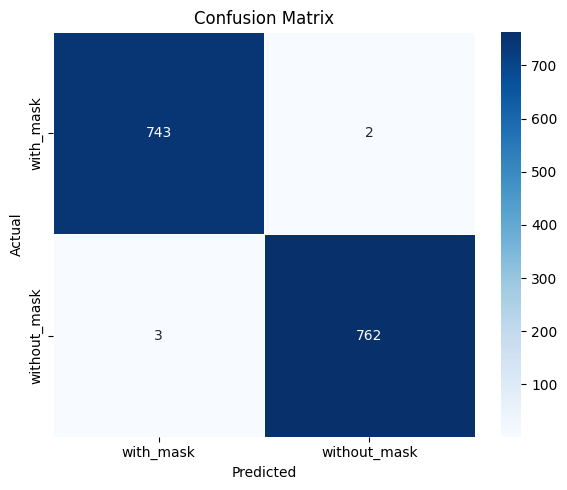

Saved: confusion_matrix.png


In [ ]:
# ── Cell 12: Confusion Matrix + Classification Report ─────────────────────────
val_gen.reset()

# Get predictions
y_pred_probs = model.predict(val_gen, steps=len(val_gen), verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes

# Trim to same length (last batch may be partial)
min_len = min(len(y_true), len(y_pred))
y_true, y_pred = y_true[:min_len], y_pred[:min_len]

# Classification Report
print('\nClassification Report:')
print('─' * 50)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

In [ ]:
# ── Cell 13: Save Model ────────────────────────────────────────────────────────
MODEL_PATH = 'face_mask_detector_final.keras'
model.save(MODEL_PATH)
print(f'Final model saved : {MODEL_PATH}')
print(f'Best checkpoint   : best_mask_model.keras')

Final model saved : face_mask_detector_final.keras
Best checkpoint   : best_mask_model.keras
